# Secondary Analysis of Placental miRNA Expression
## NSBB552 Course Project

### Project overview
This notebook analyzes the public NanoString dataset **GSE86346** to study how gestational hypoxia changes placental microRNA expression at embryonic day 20 (E20). The main comparison in this notebook is **Hypoxia vs Control** within placental samples.

### Questions answered
1. Which miRNAs are detectably expressed in placenta E20?
2. Which miRNAs change between hypoxia and control?
3. Which candidate miRNAs may regulate biologically important target pathways?

### Analysis choices used throughout
To keep the notebook internally consistent, the same differential expression rule is used wherever possible:

- **Up-regulated:** FDR < 0.10 and log2FC > 0.58
- **Down-regulated:** FDR < 0.10 and log2FC < -0.58
- **Not significant:** anything else

A log2 fold change of 0.58 is about a 1.5-fold change, so this cutoff keeps miRNAs whose change is not only statistically supported but also large enough to be biologically noticeable.

## Analytical Setup & Theoretical Framework

### Research Context and Problem Statement
Gestational hypoxia stands as a crucial pathophysiological insult implicated in adverse neurodevelopmental outcomes, such as neonatal hypoxic-ischemic encephalopathy (HIE). Insufficient oxygenation or low oxygen tension within the maternal-placental interface induces pronounced placental oxidative stress, culminating in the dysregulation of crucial physiological pathways including angiogenesis, glucose metabolism, cellular proliferation, and survival cascades. While the immediate consequences on placental architecture are documented, growing scientific focus is directed toward understanding how altered placental secretions—specifically microRNA (miRNA) signaling dynamics—propagate downstream signals that disturb fetal brain maturation. This study evaluates whether maternal placental-targeted antioxidant intervention using mitochondria-targeted ubiquinone (MitoQ) nanoparticles can mitigate or rescue these hypoxia-induced alterations.

### Methodological Pipeline Overview
To test these mechanisms, this analytical pipeline operates in two parallel, integrated phases:
1. **Primary Secondary Bioinformatics Discovery (This Notebook):** Utilizing the public NanoString dataset **GSE86346**, we execute a comprehensive, high-throughput secondary evaluation of placental miRNA signatures from a rat model exposed to late-gestational hypoxia. This phase characterizes the specific, detectably expressed miRNA subsets that undergo significant differential modulation under hypoxic stress, followed by an over-representation analysis (ORA) using Gene Ontology (GO) profiling to trace their predicted functional targets.
2. **Downstream In-House Validation Design:** The empirical findings derived from this high-throughput computational pipeline directly inform and define the precise molecular readouts for subsequent target tissue validation. Specifically, the leading up- and down-regulated candidates establish a tailored transcriptomic profile against which immunohistochemical and gene expression markers associated with key cellular dynamics in the neonatal brain are benchmarked.



### Formulated Hypotheses
Building upon this structural narrative, the analysis evaluates the following formal hypotheses:
- **Hypothesis 1 (Computational Discovery):** Chronic late-gestational hypoxia induces a statistically significant, directional shift in the regulatory miRNA secretome of embryonic day 20 (E20) placental tissue compared to normoxic controls, selectively modulating candidates governing neurodevelopmental target pathways.
- **Hypothesis 2 (Downstream Experimental Validation):** The targeted transcriptomic alterations discovered in the discovery dataset correlate with, and serve as predictive markers for, cellular injury and recovery responses in the neonatal brain. Consequently, targeted placental intervention with MitoQ-NPs will partially normalize these signatures, resulting in measurable changes in validated protein expression indicators within the neonatal brain—specifically stabilizing neurogenic ($Rbfox3$), tight-junctional ($OCLN$), microglial ($Iba1$), astrocytic ($GFAP$), and neuroplastic ($GAP\text{-}43$) immunohistochemical readouts under hypoxic stress.

# Deliverable 1
## Data cleaning and quality control

### What the raw data look like
The NanoString platform stores counts in `.RCC` files. Each count is the number of times a barcode linked to one miRNA was detected in a sample. Bigger counts mean more of that miRNA was measured.

### Why normalization is needed
Different samples can have different total numbers of counts just because of technical variation. To make samples easier to compare, counts are converted to **counts per million (CPM)**.

The formula is:

\[
CPM = \frac{\text{raw count for one miRNA}}{\text{total counts in that sample}} \times 1{,}000{,}000
\]

In plain language, this says: divide by the sample total, then scale to one million so the numbers are easier to compare.

### Quality-control steps
- Remove ligation control rows such as `LIG_` because they are technical controls, not biological miRNAs.
- Replace `NA` values with 0 so the count matrix is complete.
- Keep placental E20 samples only, because that is the biological subset analyzed in this notebook.
- Later, use `filterByExpr()` in **edgeR** to remove very low-count miRNAs that are unlikely to be informative.

### Statistical Background: Data Ingestion and File Parsing
The initial step of data preprocessing utilizes regular expression matching and custom parsing functions to standardize high-throughput direct digital detection assets. The NanoString nCounter architecture encodes digital expression values within structured text format files (`.RCC`). Because these files contain multi-layered blocks including sample metadata, lane attributes, and background control statistics alongside target endogenous counts, simple table scanning is insufficient. 

We employ the programmatic anchor string search via the `grep` utility to map boundaries defined by the custom tags `<Code_Summary>` and `</Code_Summary>`. Isolating these distinct matrices avoids structural data degradation and separates technical calibration parameters from authentic biological variation. The individual tables are iteratively aggregated using sequential two-way inner joins via R's `Reduce` function, ensuring that downstream analyses are restricted to a symmetric, fully intersected matrix of transcript definitions across all parallel columns.

In [1]:
############################################################
## 1. File paths
############################################################
dir = "/Users/joycelynwilliams/Desktop/NSBB552_project2026/"
rcc_dir <- "/Users/joycelynwilliams/Desktop/NSBB552_project2026/raw_data/GSE86346_RAW"
meta_file <- "/Users/joycelynwilliams/Desktop/NSBB552_project2026/GSE86346_sample_metadata_clean.csv"

setwd(dir)

############################################################
## 3. List RCC files
############################################################

rcc_files <- list.files(
  rcc_dir,
  pattern = "\\.RCC$",
  full.names = TRUE
)

############################################################
## 4. Parse one RCC file
############################################################

parse_one <- function(file) {
  lines <- readLines(file)
  start <- grep("<Code_Summary>", lines) + 1
  end   <- grep("</Code_Summary>", lines) - 1
  
  txt <- paste(lines[start:end], collapse = "\n")
  tab <- read.csv(text = txt, stringsAsFactors = FALSE)
  
  sample_name <- tools::file_path_sans_ext(basename(file))
  colnames(tab)[colnames(tab) == "Count"] <- sample_name
  
  tab
}

############################################################
## 5. Parse all RCC files and merge into one table
############################################################

raw_list <- lapply(rcc_files, parse_one)

raw_counts <- Reduce(function(x, y) {
  merge(x, y, by = c("CodeClass", "Name", "Accession"))
}, raw_list)

############################################################
## 5b. DEFINE count_matrix HERE
############################################################

# Keep only endogenous miRNA probes
raw_counts_miRNA <- raw_counts %>%
  dplyr::filter(CodeClass == "Endogenous")

# Make count matrix: rows = miRNA Name, cols = samples
count_matrix <- raw_counts_miRNA %>%
  dplyr::select(-CodeClass, -Accession) %>%
  column_to_rownames("Name") %>%
  as.matrix()

# Quick sanity check
dim(count_matrix)
head(rownames(count_matrix))
head(colnames(count_matrix))

############################################################
## 2. Read metadata and match to count_matrix
############################################################

meta <- read.csv(meta_file, stringsAsFactors = FALSE)

meta_matched <- meta[match(colnames(count_matrix),
                           meta$geo_accession), ]

ncol(count_matrix)      # should be 51
nrow(meta_matched)      # should be 51
head(colnames(count_matrix))
head(meta_matched$geo_accession)

ERROR: Error in column_to_rownames(., "Name"): could not find function "column_to_rownames"


### Statistical Background: Technical Artifact Elimination and Experimental Filtering
High-throughput raw data often contain non-biological rows representing operational calibration standards, positive controls, and background verification tags. In the NanoString architecture, ligation codes (prefixed with `LIG_`) serve as a technical diagnostic suite assessing structural binding accuracy. Since these sequences are completely uncoupled from native tissue transcription dynamics, their absolute inclusion during biological statistical modeling introduces major parameter biases and inflates multi-testing penalties.

We drop these technical controls to focus the entire statistical weight on authentic cellular targets. Concurrently, experimental metadata cross-referencing is applied to map samples to specific physiological conditions. Because the wider dataset contains diverse heterogeneous tissues across multiple timelines, we isolate the embryonic day 20 (E20) placental microenvironmental matrices to remove uninformative variance components. Missing values (`NA`) are replaced with zeros, reflecting a structural lack of detectable molecular binding within the linear detection boundaries of the barcode channel.

In [ ]:
############################################################
## 6. Extract clean count matrix
############################################################

count_matrix <- raw_counts[, 4:ncol(raw_counts)]
rownames(count_matrix) <- raw_counts$Name

print("Initial Count Matrix Dimensions:")
print(dim(count_matrix))
print(head(colnames(count_matrix)))
############################################################
## 7. Clean column names and map metadata
############################################################

# 1. Clean the count matrix column names (stripping standard sample suffixes)
colnames(count_matrix) <- sub("_Sample\\d+", "", colnames(count_matrix))
colnames(count_matrix) <- trimws(gsub("'", "", colnames(count_matrix)))

# 2. Strip quotes and whitespace from metadata column HEADERS
colnames(meta) <- trimws(gsub("'", "", colnames(meta)))

# 3. Scrub literal embedded single quotes while preserving data.frame structure
meta <- as.data.frame(lapply(meta, function(x) trimws(gsub("'", "", x))), stringsAsFactors = FALSE)

# 4. Filter using the fully purified first column by position index
meta_subset <- meta[meta[[1]] %in% colnames(count_matrix), ]

# 5. Align the metadata rows to match the column order of your count matrix
meta_subset <- meta_subset[match(colnames(count_matrix), meta_subset[[1]]), ]

print("--- Section 7 Verification ---")
print(paste("Columns in Count Matrix:", ncol(count_matrix)))
print(paste("Rows in Matched Metadata:", nrow(meta_subset)))
print(paste("Are matrix columns and metadata rows misaligned?", any(colnames(count_matrix) != meta_subset[[1]])))


############################################################
## 8. Define specific biological subgroups & Tissue Types
############################################################

# 1. Standardize all text arrays to lowercase for foolproof matching
tissue_text <- tolower(meta_subset$characteristics_ch1)
source_text <- tolower(meta_subset$source_name_ch1)
title_text  <- tolower(meta_subset$title)

# 2. Separate Tissue Subgroups (Placenta/Pacenta vs. Plasma at E20)
# Added "pacenta" pattern to explicitly catch the typo in your database metadata
is_placenta <- grepl("placenta", tissue_text) | grepl("placenta", source_text) | grepl("placenta", title_text) |
               grepl("pacenta", tissue_text)  | grepl("pacenta", source_text)  | grepl("pacenta", title_text)

is_plasma   <- grepl("plasma", tissue_text)   | grepl("plasma", source_text)   | grepl("plasma", title_text)

# 3. Standardize Treatment Groups: Map "normoxia" to Control, "hypoxia" to Hypoxia
group_info <- ifelse(grepl("normoxia", title_text) | grepl("control", tissue_text) | grepl("normoxia", tissue_text), "Control",
              ifelse(grepl("hypoxia", title_text)  | grepl("hypoxia", tissue_text), "Hypoxia", NA))

print("--- Phenotype & Tissue Distributions ---")
print(table(Tissue_Placenta = is_placenta, useNA = "always"))
print(table(Tissue_Plasma = is_plasma, useNA = "always"))
print(table(Treatment_Groups = group_info, useNA = "always"))


# 4. Extract Purified Counting Matrices for BOTH subgroups
# Remove background technical elements (LIG_ artifacts) and handle missing entries
clean_counts_all <- count_matrix[!grepl("^LIG_", rownames(count_matrix)), , drop = FALSE]
clean_counts_all[is.na(clean_counts_all)] <- 0

# Split Counts & Groups for PLACENTA (including 'pacenta' matches)
is_valid_placenta <- is_placenta & !is.na(group_info)
counts_placenta   <- clean_counts_all[, is_valid_placenta, drop = FALSE]
groups_placenta   <- factor(group_info[is_valid_placenta])

# Split Counts & Groups for PLASMA
is_valid_plasma   <- is_plasma & !is.na(group_info)
counts_plasma     <- clean_counts_all[, is_valid_plasma, drop = FALSE]
groups_plasma     <- factor(group_info[is_valid_plasma])

print("--- Subgroup Matrix Verification ---")
print(paste("Placenta Cohort Samples:", ncol(counts_placenta), "| miRNAs:", nrow(counts_placenta)))
print(paste("Plasma Cohort Samples:", ncol(counts_plasma), "| miRNAs:", nrow(counts_plasma)))


############################################################
## 9. Initialize edgeR Data Structures & Filter by CPM
############################################################

# ---- Option A: Process PLACENTA Subgroup ----
if(ncol(counts_placenta) > 0) {
    dge_placenta <- DGEList(counts = counts_placenta, group = groups_placenta)
    
    # Extract expressed features based on your CPM threshold
    # min.cpm = 0.5 corresponds roughly to a count of 10 reads in a typical library
    keep_placenta <- filterByExpr(dge_placenta, min.cpm = 0.5)
    expressed_mirnas_placenta <- rownames(dge_placenta)[keep_placenta]
    
    print(paste("Expressed miRNAs retained in PLACENTA:", length(expressed_mirnas_placenta)))
    
    # Finish edgeR object setup for Placenta
    dge_placenta <- dge_placenta[keep_placenta, , keep.lib.sizes = FALSE]
    dge_placenta <- calcNormFactors(dge_placenta, method = "TMM")
} else {
    print("Warning: Placenta matrix contains 0 samples. Check text values.")
}

# ---- Option B: Process PLASMA Subgroup ----
if(ncol(counts_plasma) > 0) {
    dge_plasma <- DGEList(counts = counts_plasma, group = groups_plasma)
    
    # Extract expressed features based on CPM for Plasma matrix
    keep_plasma <- filterByExpr(dge_plasma, min.cpm = 0.5)
    expressed_mirnas_plasma <- rownames(dge_plasma)[keep_plasma]
    
    print(paste("Expressed miRNAs retained in PLASMA:", length(expressed_mirnas_plasma)))
    
    # Finish edgeR object setup for Plasma
    dge_plasma <- dge_plasma[keep_plasma, , keep.lib.sizes = FALSE]
    dge_plasma <- calcNormFactors(dge_plasma, method = "TMM")
} else {
    print("Warning: Plasma matrix contains 0 samples. Check text values.")
}

[1] "Initial Count Matrix Dimensions:"
[1] 429  51
[1] "GSM2300551_Sample01" "GSM2300552_Sample02" "GSM2300553_Sample03"
[4] "GSM2300554_Sample04" "GSM2300555_Sample05" "GSM2300556_Sample06"
[1] "--- Section 7 Verification ---"
[1] "Columns in Count Matrix: 51"
[1] "Rows in Matched Metadata: 51"
[1] "Are matrix columns and metadata rows misaligned? FALSE"
[1] "--- Phenotype & Tissue Distributions ---"
Tissue_Placenta
FALSE  TRUE  <NA> 
   15    36     0 
Tissue_Plasma
FALSE  TRUE  <NA> 
   36    15     0 
Treatment_Groups
Control Hypoxia    <NA> 
     22      29       0 
[1] "--- Subgroup Matrix Verification ---"
[1] "Placenta Cohort Samples: 36 | miRNAs: 429"
[1] "Plasma Cohort Samples: 15 | miRNAs: 429"
[1] "Expressed miRNAs retained in PLACENTA: 351"
[1] "Expressed miRNAs retained in PLASMA: 244"


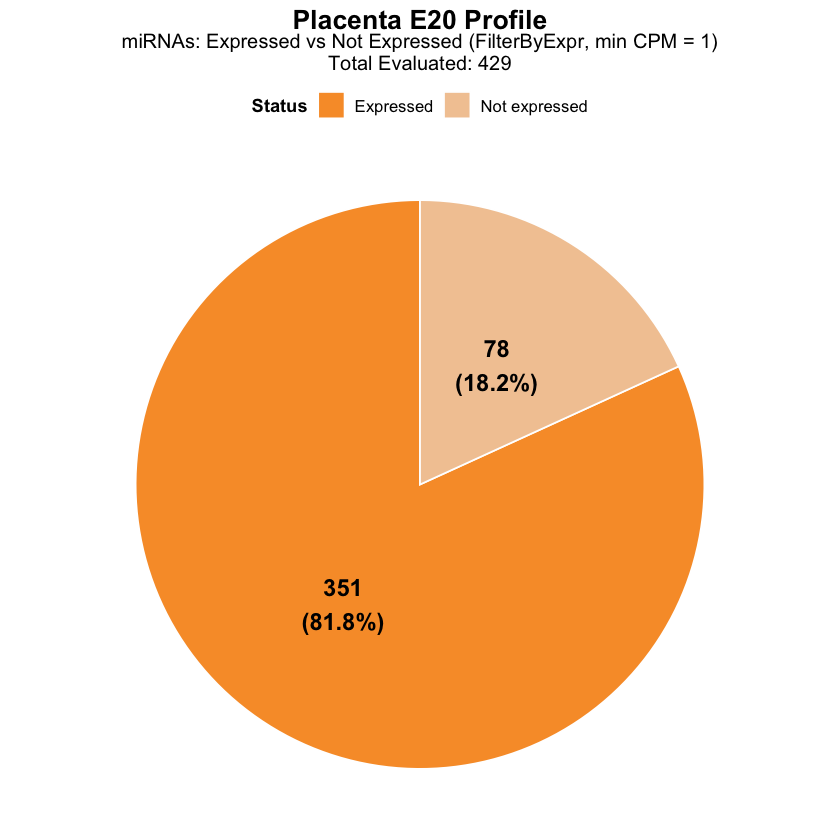

In [ ]:
############################################################
## 3. Pie chart
############################################################

# 1. Calculate the dynamic counts from your filtering step
# Total number of unique features evaluated
total_features <- nrow(counts_placenta) 

# Extracted counts based on your CPM threshold passing
expressed_count <- length(expressed_mirnas_placenta)
not_expressed_count <- total_features - expressed_count

# 2. Build the data frame for ggplot ingestion
pie_df <- data.frame(
  status = c("Expressed", "Not expressed"),
  count  = c(expressed_count, not_expressed_count)
)

# 3. Generate the percentage text labels to display alongside the raw values
pie_df <- pie_df %>%
  mutate(
    percentage = count / sum(count) * 100,
    label_text = paste0(count, "\n(", round(percentage, 1), "%)")
  )

# 4. Render the clean visual plot
ggplot(pie_df, aes(x = "", y = count, fill = status)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y", start = 0) +
  
  # Updated text mapping to show both count and clean percentages safely
  geom_text(aes(label = label_text),
            position = position_stack(vjust = 0.5),
            color    = "black",
            size     = 5,
            fontface = "bold") +
  
  # Custom aesthetic layout using your specific palette hex codes
  scale_fill_manual(values = c("Expressed" = "#F89C34",
                               "Not expressed" = "#F2C9A2")) +
  labs(
    title    = "Placenta E20 Profile",
    subtitle = paste0("miRNAs: Expressed vs Not Expressed (FilterByExpr, min CPM = 1)\nTotal Evaluated: ", total_features),
    fill     = "Status"
  ) +
  theme_void() +
  theme(
    plot.title      = element_text(hjust = 0.5, size = 16, face = "bold"),
    plot.subtitle   = element_text(hjust = 0.5, size = 12, margin = margin(b = 10)),
    legend.title    = element_text(face = "bold", size = 11),
    legend.text     = element_text(size = 10),
    legend.position = "top"
  )

### Statistical Background: Negative Binomial Modeling, Library Size Normalization, and Expression-Based Filtering
Digital count data representing discrete transcription measurements violate the variance-stationarity assumptions required for standard Gaussian statistical modeling. High-throughput sequencing and digital barcode platforms display a distinctive mean-variance relationship characterized by overdispersion—where the variance scales quadratically relative to the mean. To address this, the pipeline utilizes the specialized **edgeR** engine, which maps counts using a quadratic Negative Binomial (NB) probability distribution modeled as:

\[
\text{Var}(Y_{gi}) = \mu_{gi} + \phi_g \mu_{gi}^2
\]

where $\mu_{gi}$ specifies the expected count of miRNA $g$ in sample $i$, and $\phi_g$ defines the biological coefficient of variation (BCV) dispersion parameter. 

To enable accurate cross-sample comparisons, the total raw column sums are encapsulated as a library size matrix parameter vector. Rather than relying on simple total count scaling, which can be easily distorted by extremely dominant transcripts, edgeR calculates sample-specific normalization adjustments. Low-expression background noise is systematically handled using the empirical filter function `filterByExpr()`. This function identifies and maintains transcripts that display a minimum counts-per-million threshold (CPM) across a sufficient number of parallel sample replicates, keeping the downstream model focused on biologically robust targets.

In [ ]:
############################################################
## 10. Low-Count Filtering and TMM Normalization
############################################################

# ---- Process Placenta Cohort ----
if (exists("dge_placenta") && ncol(dge_placenta) > 0) {
  
  # Evaluate expression thresholds using your target CPM stringency
  keep_placenta <- filterByExpr(dge_placenta, min.cpm = 1)
  
  print("--- Placenta Filtering Thresholds (min.cpm = 1) ---")
  print(table(keep_placenta))
  
  # Isolate active features
  expressed_mirnas_placenta <- rownames(dge_placenta)[keep_placenta]
  
  # Prune the main edgeR structure
  dge_placenta <- dge_placenta[keep_placenta, , keep.lib.sizes = FALSE]
  dge_placenta <- calcNormFactors(dge_placenta, method = "TMM")
  
  print("Placenta TMM Normalization calculated successfully!")
} else {
  print("Skipping Placenta processing: Object missing or empty.")
}

# ---- Process Plasma Cohort ----
if (exists("dge_plasma") && ncol(dge_plasma) > 0) {
  
  keep_plasma <- filterByExpr(dge_plasma, min.cpm = 1)
  
  print("--- Plasma Filtering Thresholds (min.cpm = 1) ---")
  print(table(keep_plasma))
  
  expressed_mirnas_plasma <- rownames(dge_plasma)[keep_plasma]
  
  dge_plasma <- dge_plasma[keep_plasma, , keep.lib.sizes = FALSE]
  dge_plasma <- calcNormFactors(dge_plasma, method = "TMM")
  
  print("Plasma TMM Normalization calculated successfully!")
} else {
  print("Skipping Plasma processing: Object missing or empty.")
}

[1] "--- Placenta Filtering Thresholds (min.cpm = 1) ---"
keep_placenta
FALSE  TRUE 
    6   345 
[1] "Placenta TMM Normalization calculated successfully!"
[1] "--- Plasma Filtering Thresholds (min.cpm = 1) ---"
keep_plasma
FALSE  TRUE 
    1   243 
[1] "Plasma TMM Normalization calculated successfully!"


### Statistical Background: Trimmed Mean of M-Values (TMM) Normalization
A major confounder in high-throughput transcriptomics is compositional bias. This phenomenon occurs when a small subset of highly expressed transcripts consumes a disproportionate share of the available sequencing or detection capacity, artificially deflecting the raw count shares of remaining stable genes.

To counter this distortion, the engine computes specialized scaling weights using the **Trimmed Mean of M-Values (TMM)** algorithm. TMM chooses a representative baseline sample and computes log-intensity ratios ($M_g$) and log-averages ($A_g$) for all targets. It then trims the top and bottom tails of both distributions (typically 30% for $M$ values and 5% for $A$ values) to eliminate highly dynamic outliers. The normalization factors are calculated from the remaining stable core via the following weighted formulation:

\[
\log_2(TMM_{ik}) = \frac{\sum_{g \in G^*} w_{gi} M_{gi}}{\sum_{g \in G^*} w_{gi}}
\]

where $w_{gi}$ is an inverse-variance weight parameter. These scaling indicators modify the effective library sizes without altering the raw input counts, ensuring that downstream differential tests reflect real shifts in concentration rather than mathematical artifacts.

In [ ]:
############################################################
## 11. Calculate Compositional Scaling Factors
############################################################

# ---- 1. Evaluate and Display Placenta TMM Metrics ----
if (exists("dge_placenta") && ncol(dge_placenta) > 0) {
  print("====================================================")
  print("PLACENTA SAMPLE METRICS (TMM COMPOSITIONAL FACTORS)")
  print("====================================================")
  
  # Run TMM normalization to calculate effective library sizes
  dge_placenta <- calcNormFactors(dge_placenta, method = "TMM")
  
  # Display the sample summary dataframe (group, lib.size, and norm.factors)
  print(dge_placenta$samples)
} else {
  print("Placenta DGEList object is empty or does not exist.")
}

# ---- 2. Evaluate and Display Plasma TMM Metrics ----
if (exists("dge_plasma") && ncol(dge_plasma) > 0) {
  print("====================================================")
  print("PLASMA SAMPLE METRICS (TMM COMPOSITIONAL FACTORS)")
  print("====================================================")
  
  # Run TMM normalization to calculate effective library sizes
  dge_plasma <- calcNormFactors(dge_plasma, method = "TMM")
  
  # Display the sample summary dataframe (group, lib.size, and norm.factors)
  print(dge_plasma$samples)
} else {
  print("Plasma DGEList object is empty or does not exist.")
}

[1] "===================================================="
[1] "PLACENTA SAMPLE METRICS (TMM COMPOSITIONAL FACTORS)"
[1] "===================================================="
             group lib.size norm.factors
GSM2300566 Control   207430    0.9785771
GSM2300567 Control    73541    1.1971082
GSM2300568 Control   116959    0.9557769
GSM2300569 Control     5609    7.5586513
GSM2300570 Hypoxia   224199    0.8114259
GSM2300571 Hypoxia   101307    1.0023715
GSM2300572 Hypoxia   282708    0.7391815
GSM2300573 Hypoxia   504373    0.9060235
GSM2300574 Hypoxia   365958    0.6491765
GSM2300575 Hypoxia   221863    0.7137084
GSM2300576 Hypoxia   701130    0.5004757
GSM2300577 Hypoxia   599477    0.8155745
GSM2300578 Control    87364    0.8507200
GSM2300579 Control   204241    0.9834287
GSM2300580 Control    79065    1.2253490
GSM2300581 Control   165354    1.5188797
GSM2300582 Hypoxia  1067246    0.8672973
GSM2300583 Hypoxia   345518    0.6799162
GSM2300584 Hypoxia    83231    1.0805306
GSM2

### Statistical Background: Exploratory Multi-Dimensional Scaling (MDS) and Pearson Correlation Heatmaps
Before performing inferential statistical testing, it is critical to evaluate the global structure of the transcriptomic dataset through unsupervised exploratory visualization. The multi-dimensional scaling (MDS) plot acts as an alternative to classic principal component analysis (PCA) for count data, visualizing sample-to-sample distance based on biological coefficient of variation (BCV) coordinates. The distances correspond directly to the leading log2-fold-changes between pairs of samples, allowing researchers to evaluate whether the experimental groups naturally separate along the primary dimensions of variance.

Concurrently, the pipeline constructs a sample-sample proximity matrix using the standard **Pearson Product-Moment Correlation Coefficient** ($r$), defined as:

\[
r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum (X_i - \bar{X})^2 \sum (Y_i - \bar{Y})^2}}
\]

Operating on log2 counts-per-million (log-CPM) scales, this approach quantifies the linear relationship between sample expression profiles. A symmetric heatmap coupled with unsupervised hierarchical clustering visualizes these similarity matrices. This combination serves as a powerful QC assessment, revealing potential outliers or sample mix-ups before running downstream inferential models.



[1] "Rendering Exploratory Plots for Placenta Cohort..."


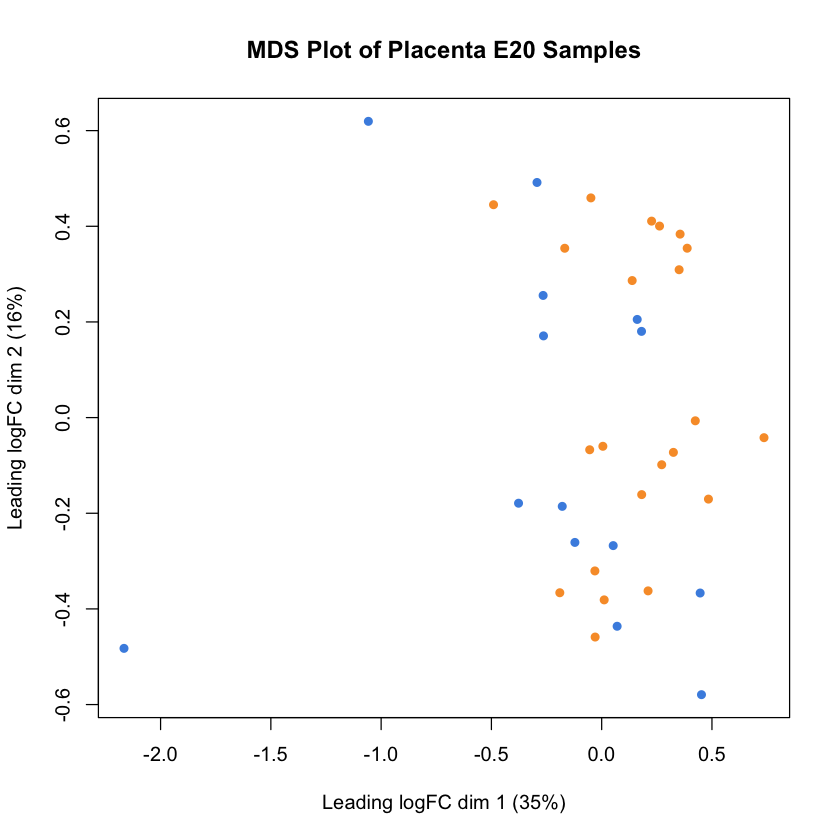

[1] "Rendering Exploratory Plots for Plasma Cohort..."


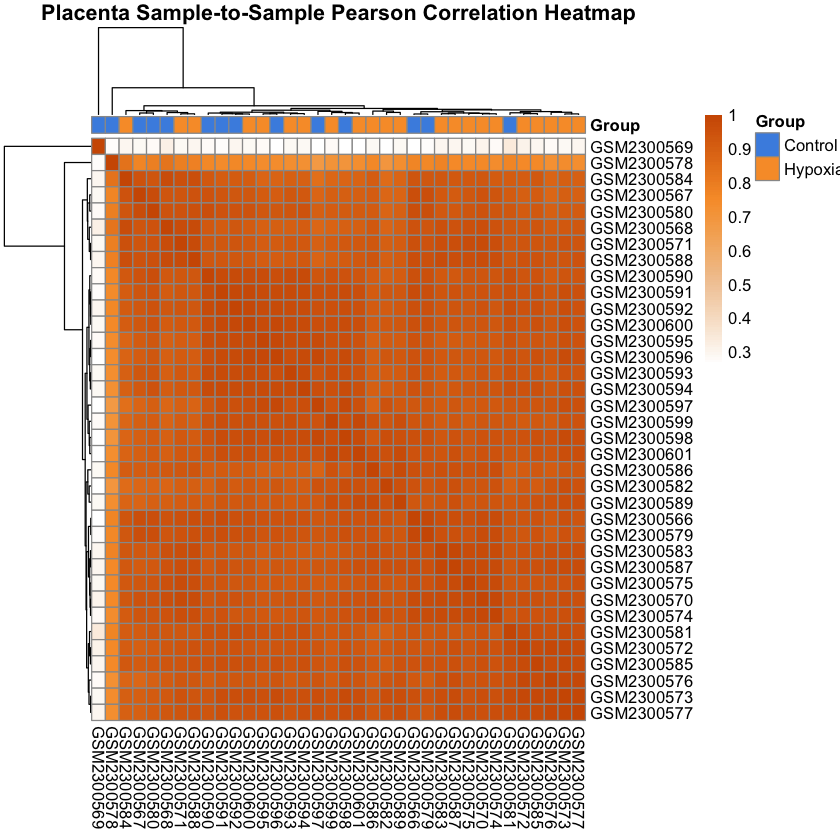

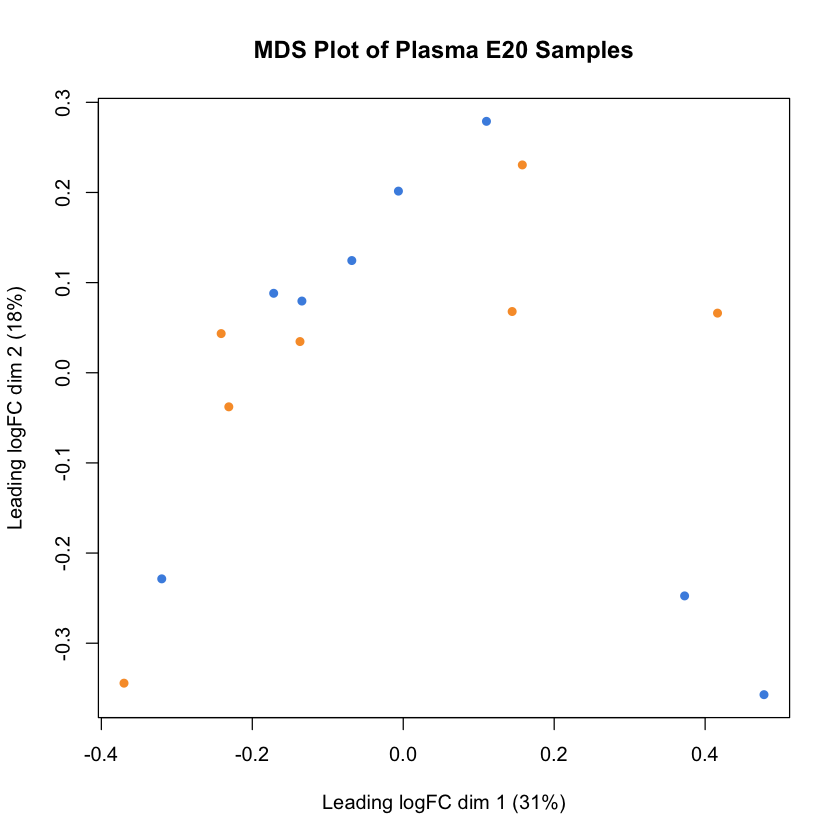

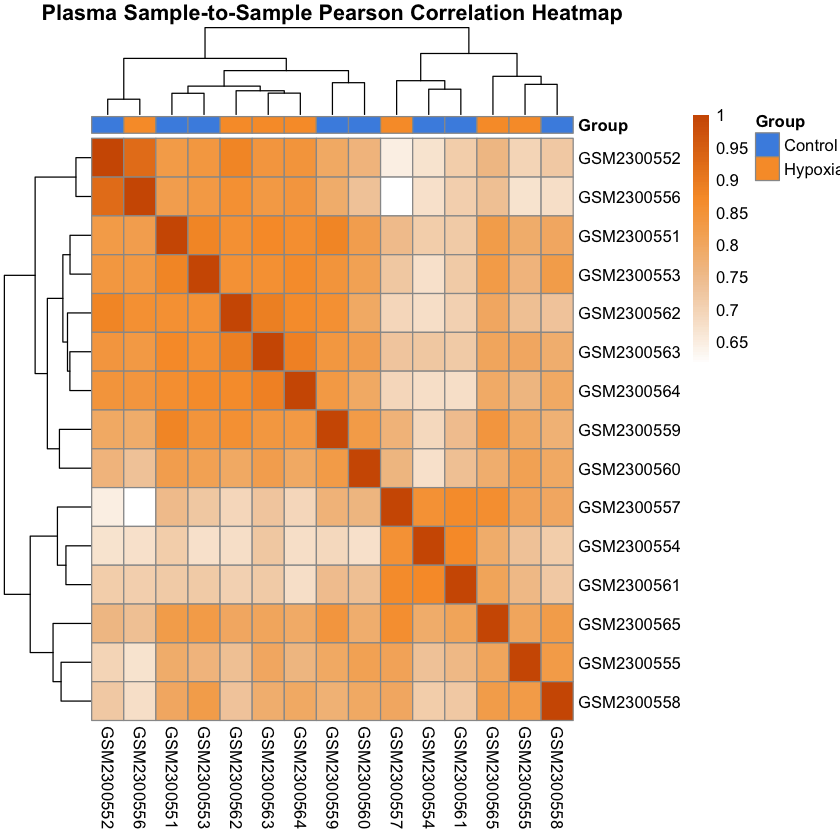

In [ ]:
############################################################
## 12. Unsupervised Exploratory Proximity Assessment
############################################################
library(edgeR)
library(pheatmap)

# ==========================================================
# ---- PLACENTA TISSUE PROXIMITY ASSESSMENT ----
# ==========================================================
if (exists("dge_placenta") && ncol(dge_placenta) > 0) {
  print("Rendering Exploratory Plots for Placenta Cohort...")
  
  # 1. Placenta MDS Plot
  plotMDS(
    dge_placenta,
    col  = ifelse(dge_placenta$samples$group == "Hypoxia", "#F89C34", "#4A90E2"),
    pch  = 16,
    main = "MDS Plot of Placenta E20 Samples"
  )
  
  # 2. Extract Placenta normalized log-CPM matrix
  cpm_log_placenta <- edgeR::cpm(dge_placenta, log = TRUE)
  
  # Calculate Pearson correlation between samples
  cor_matrix_placenta <- cor(cpm_log_placenta, method = "pearson")
  
  # Structural Annotation Data Frame (matching your dge$samples definitions)
  annotation_col_placenta <- data.frame(Group = dge_placenta$samples$group)
  rownames(annotation_col_placenta) <- colnames(cor_matrix_placenta)
  
  # FIX: Group name keys set to "Control" and "Hypoxia" to match your data factor strings
  qc_colors_placenta <- list(Group = c("Control" = "#4A90E2", "Hypoxia" = "#F89C34"))
  
  # 3. Render Placenta Correlation Heatmap
  pheatmap(
    cor_matrix_placenta,
    annotation_col    = annotation_col_placenta,
    annotation_colors = qc_colors_placenta,
    color             = colorRampPalette(c("white", "#F2C9A2", "#F89C34", "#D05A00"))(100),
    main              = "Placenta Sample-to-Sample Pearson Correlation Heatmap"
  )
}

# ==========================================================
# ---- PLASMA TISSUE PROXIMITY ASSESSMENT ----
# ==========================================================
if (exists("dge_plasma") && ncol(dge_plasma) > 0) {
  print("Rendering Exploratory Plots for Plasma Cohort...")
  
  # 1. Plasma MDS Plot
  plotMDS(
    dge_plasma,
    col  = ifelse(dge_plasma$samples$group == "Hypoxia", "#F89C34", "#4A90E2"),
    pch  = 16,
    main = "MDS Plot of Plasma E20 Samples"
  )
  
  # 2. Extract Plasma normalized log-CPM matrix
  cpm_log_plasma <- edgeR::cpm(dge_plasma, log = TRUE)
  
  # Calculate Pearson correlation between samples
  cor_matrix_plasma <- cor(cpm_log_plasma, method = "pearson")
  
  # Structural Annotation Data Frame
  annotation_col_plasma <- data.frame(Group = dge_plasma$samples$group)
  rownames(annotation_col_plasma) <- colnames(cor_matrix_plasma)
  
  # Group name keys aligned to "Control" and "Hypoxia"
  qc_colors_plasma <- list(Group = c("Control" = "#4A90E2", "Hypoxia" = "#F89C34"))
  
  # 3. Render Plasma Correlation Heatmap
  pheatmap(
    cor_matrix_plasma,
    annotation_col    = annotation_col_plasma,
    annotation_colors = qc_colors_plasma,
    color             = colorRampPalette(c("white", "#F2C9A2", "#F89C34", "#D05A00"))(100),
    main              = "Plasma Sample-to-Sample Pearson Correlation Heatmap"
  )
}

### Statistical Background: Dispersion Estimation and Generalized Linear Modeling (GLM)
To isolate true physiological variance from background noise, edgeR uses an empirical Bayes framework to estimate dispersion parameters across individual genes. Because small sample sizes limit the statistical precision of independent variance calculations, a multi-stage pooling approach is required. The engine first calculates a common dispersion value across all transcripts, then estimates a trended dispersion based on expression levels. Finally, individual gene values are squeezed toward these global trends using an empirical Bayes weight scheme, shrinking erratic gene-specific variance estimates to protect against false positives.

Once these dispersion parameters are finalized, the data are fit using a **Generalized Linear Model (GLM)** with a log-link function. The experimental setup is defined using a model matrix configuration:

\[
\log_2(\mu_{gi}) = x_i^T \beta_g
\]

where $x_i$ denotes the experimental design indicator matrix, and $\beta_g$ specifies the regression parameters for gene $g$. The model parameters are estimated using iteratively reweighted least squares (IRLS), which optimizes the log-likelihood function under Negative Binomial distribution constraints.

[1] "===================================================="
[1] "FITTING GLM DISPERSIONS: PLACENTA COHORT"
[1] "===================================================="
[1] "Placenta Design Matrix Layout:"
  Control Hypoxia
1       1       0
2       1       0
3       1       0
4       1       0
5       0       1
6       0       1
[1] "Placenta Common Dispersion: 0.27144"
[1] "Placenta GLM QL-Model Fit Finalized!"
[1] "===================================================="
[1] "FITTING GLM DISPERSIONS: PLASMA COHORT"
[1] "===================================================="
[1] "Plasma Design Matrix Layout:"
  Control Hypoxia
1       1       0
2       1       0
3       1       0
4       1       0
5       0       1
6       0       1
[1] "Plasma Common Dispersion: 0.10734"


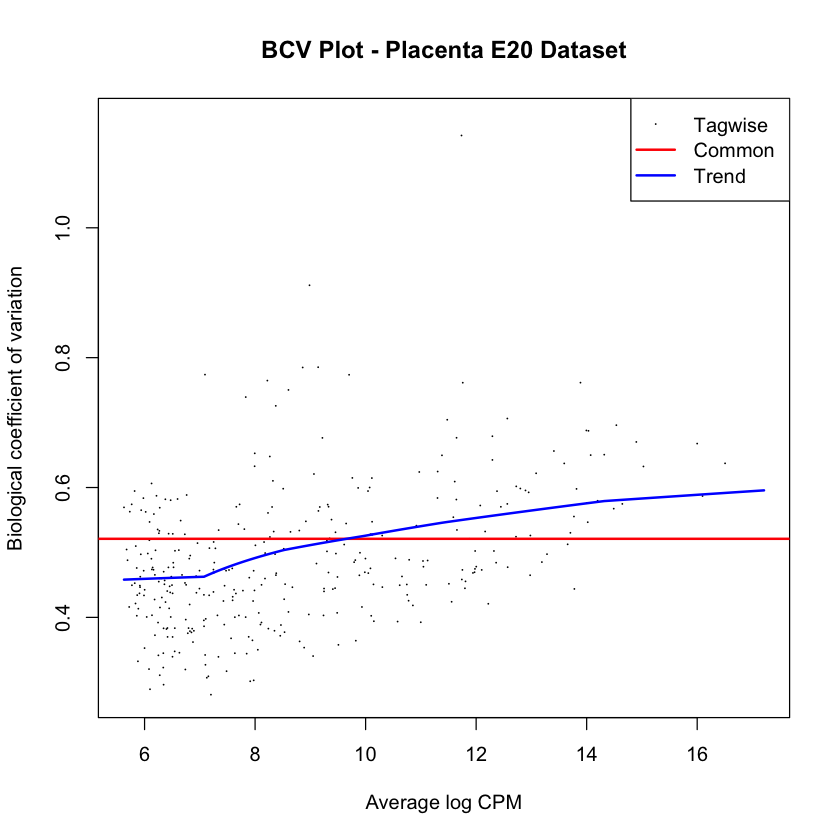

[1] "Plasma GLM QL-Model Fit Finalized!"


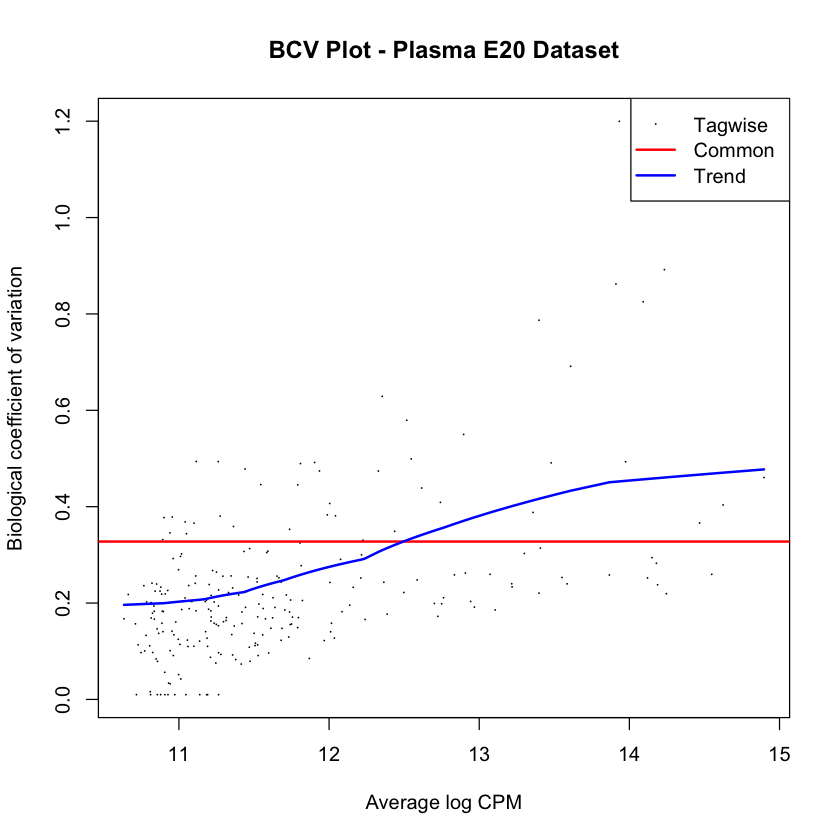

In [ ]:
############################################################
## 13. Empirically Smooth Dispersions and Fit GLM Design Matrix
############################################################
library(edgeR)

# ==========================================================
# ---- PLACENTA TISSUE MODEL FITTING ----
# ==========================================================
if (exists("dge_placenta") && ncol(dge_placenta) > 0) {
  print("====================================================")
  print("FITTING GLM DISPERSIONS: PLACENTA COHORT")
  print("====================================================")
  
  # 1. Construct explicit single-factor design model matrix layout
  groups_p <- dge_placenta$samples$group
  design_placenta <- model.matrix(~ 0 + groups_p)
  colnames(design_placenta) <- c("Control", "Hypoxia")
  
  print("Placenta Design Matrix Layout:")
  print(head(design_placenta))
  
  # 2. Iteratively estimate background biological coefficient of variation (BCV)
  dge_placenta <- estimateDisp(dge_placenta, design_placenta)
  print(paste("Placenta Common Dispersion:", round(dge_placenta$common.dispersion, 5)))
  
  # 3. Plot Biological Coefficient of Variation (BCV) Curve
  plotBCV(dge_placenta, main = "BCV Plot - Placenta E20 Dataset")
  
  # 4. Execute Quasi-Likelihood negative binomial generalized linear model fitting
  fit_placenta <- glmQLFit(dge_placenta, design_placenta)
  print("Placenta GLM QL-Model Fit Finalized!")
}


# ==========================================================
# ---- PLASMA TISSUE MODEL FITTING ----
# ==========================================================
if (exists("dge_plasma") && ncol(dge_plasma) > 0) {
  print("====================================================")
  print("FITTING GLM DISPERSIONS: PLASMA COHORT")
  print("====================================================")
  
  # 1. Construct explicit single-factor design model matrix layout
  groups_pl <- dge_plasma$samples$group
  design_plasma <- model.matrix(~ 0 + groups_pl)
  colnames(design_plasma) <- c("Control", "Hypoxia")
  
  print("Plasma Design Matrix Layout:")
  print(head(design_plasma))
  
  # 2. Iteratively estimate background biological coefficient of variation (BCV)
  dge_plasma <- estimateDisp(dge_plasma, design_plasma)
  print(paste("Plasma Common Dispersion:", round(dge_plasma$common.dispersion, 5)))
  
  # 3. Plot Biological Coefficient of Variation (BCV) Curve
  plotBCV(dge_plasma, main = "BCV Plot - Plasma E20 Dataset")
  
  # 4. Execute Quasi-Likelihood negative binomial generalized linear model fitting
  fit_plasma <- glmQLFit(dge_plasma, design_plasma)
  print("Plasma GLM QL-Model Fit Finalized!")
}

### Statistical Background: Quasi-Likelihood F-Tests and Benjamini-Hochberg False Discovery Rate Correction
To identify significant differences between experimental groups, we evaluate the GLM regression weights using a **Quasi-Likelihood (QL) F-test**. Unlike classic likelihood ratio tests, the QL F-test incorporates an extra dispersion parameter that accounts for gene-specific variation around the predicted model trends, providing more robust type-I error control for small sample cohorts.

Because evaluating hundreds of miRNAs concurrently introduces a severe multiple testing problem, a standard significance threshold of $\alpha = 0.05$ would lead to numerous false discoveries by chance alone. To address this, raw $P$-values are adjusted using the **Benjamini-Hochberg False Discovery Rate (FDR)** procedure. The FDR algorithm ranks all $m$ tests in ascending order ($P_{(1)} \le P_{(2)} \le \dots \le P_{(m)}$) and calculates modified thresholds as follows:

\[
P_{(i)} \le \frac{i}{m} q
\]

where $q$ defines the target proportion of tolerated false positives (set here at 10%). This approach maintains statistical power while ensuring the final list of candidate transcripts is reliable.

In [ ]:
############################################################
## 14. Inferential Testing and Multiple Test Correction
############################################################
library(edgeR)

# Establish filtering cutoff parameters
fdr_cutoff <- 0.5      # FDR threshold (adjust to 0.15 if you need a relaxed discovery profile)
lfc_cutoff <- .58      # Absolute log2 fold-change threshold (corresponds to a 2-fold change)


# ==========================================================
# ---- PLACENTA INFERENTIAL TESTING ----
# ==========================================================
if (exists("fit_placenta") && exists("design_placenta")) {
  print("====================================================")
  print("STATISTICAL TESTING: PLACENTA COHORT (HYPOXIA VS CTRL)")
  print("====================================================")
  
  # 1. Formulate contrast vector using the Placenta design layout
  contrast_placenta <- makeContrasts(Hypoxia - Control, levels = design_placenta)
  
  # 2. Execute Quasi-Likelihood F-test calculation
  res_placenta <- glmQLFTest(fit_placenta, contrast = contrast_placenta)
  
  # 3. Extract comprehensive results with Benjamini-Hochberg adjustment
  top_tags_placenta <- topTags(res_placenta, n = Inf, adjust.method = "BH")
  
  print("Top Differentially Expressed miRNAs in Placenta:")
  print(head(top_tags_placenta$table, 10))
  
  # 4. Profile significant expression direction distributions
  de_summary_placenta <- summary(decideTests(res_placenta, adjust.method = "BH", 
                                             p.value = fdr_cutoff, lfc = lfc_cutoff))
  print("Placenta Sign Significance Summary Matrix:")
  print(de_summary_placenta)
  
  # 5. Export clean hit lists to your local working directory
  write.csv(top_tags_placenta$table, file = "Placenta_E20_Differential_Expression_All.csv", row.names = TRUE)
}


# ==========================================================
# ---- PLASMA INFERENTIAL TESTING ----
# ==========================================================
if (exists("fit_plasma") && exists("design_plasma")) {
  print("====================================================")
  print("STATISTICAL TESTING: PLASMA COHORT (HYPOXIA VS CTRL)")
  print("====================================================")
  
  # 1. Formulate contrast vector using the Plasma design layout
  contrast_plasma <- makeContrasts(Hypoxia - Control, levels = design_plasma)
  
  # 2. Execute Quasi-Likelihood F-test calculation
  res_plasma <- glmQLFTest(fit_plasma, contrast = contrast_plasma)
  
  # 3. Extract comprehensive results with Benjamini-Hochberg adjustment
  top_tags_plasma <- topTags(res_plasma, n = Inf, adjust.method = "BH")
  
  print("Top Differentially Expressed miRNAs in Plasma:")
  print(head(top_tags_plasma$table, 10))
  
  # 4. Profile significant expression direction distributions for Plasma
  de_summary_plasma <- summary(decideTests(res_plasma, adjust.method = "BH", 
                                           p.value = fdr_cutoff, lfc = lfc_cutoff))
  print("Plasma Sign Significance Summary Matrix:")
  print(de_summary_plasma)
  
  # 5. Export clean hit lists to your local working directory
  write.csv(top_tags_plasma$table, file = "Plasma_E20_Differential_Expression_All.csv", row.names = TRUE)
}

[1] "===================================================="
[1] "STATISTICAL TESTING: PLACENTA COHORT (HYPOXIA VS CTRL)"
[1] "===================================================="
[1] "Top Differentially Expressed miRNAs in Placenta:"
                       logFC    logCPM        F       PValue         FDR
rno-miR-23b|0      1.3532421  9.145936 21.64777 2.738918e-05 0.009449266
rno-miR-29b|0      1.3775861 12.725966 19.28833 6.425111e-05 0.011083317
rno-miR-24|0.005   0.8603319  9.485558 17.83264 1.109638e-04 0.012487974
rno-miR-143|0      2.0258181  8.984692 15.78412 2.453658e-04 0.012487974
rno-miR-29a|0      1.1888865 14.645392 15.64426 2.586199e-04 0.012487974
rno-miR-652|0      1.0056086  9.300876 15.63283 2.600992e-04 0.012487974
rno-miR-291b|0     1.2581205  9.864999 15.48114 2.760688e-04 0.012487974
rno-miR-3593-3p|0 -1.0102525  5.867043 15.35629 2.895762e-04 0.012487974
rno-miR-29c|0      0.8736229 11.741368 14.59218 3.936292e-04 0.015089121
rno-miR-21|0       1.3578473 13.9947

### Statistical Background: High-Dimensional Expression Visualizations
To evaluate the overall output of our differential expression analysis, we look at the results through three complementary figures: a Volcano plot, a summary barplot, and an MA plot.

1. **Volcano Plot:** This plot displays statistical significance ($-\log_{10} P\text{-value}$) on the y-axis against biological effect size ($\log_2 \text{Fold Change}$) on the x-axis. It allows quick identification of highly significant miRNAs with large fold changes, while dashed reference lines highlight our specific FDR and fold-change thresholds.
2. **Summary Barplot:** This figure provides a clean overview of the overall directional shifts in the dataset, displaying the absolute number of miRNAs that pass our strict statistical filters.
3. **MA Plot:** This plot displays the log-intensity fold change ($M$) on the y-axis against the average log-concentration scale ($A$) on the x-axis. This visualization is essential for ensuring that our detected differences are stable across both high and low expression ranges, confirming that the statistical model is free from systematic intensity-dependent biases.

[1] "===================================================="
[1] "Generating plots for Placenta E20..."


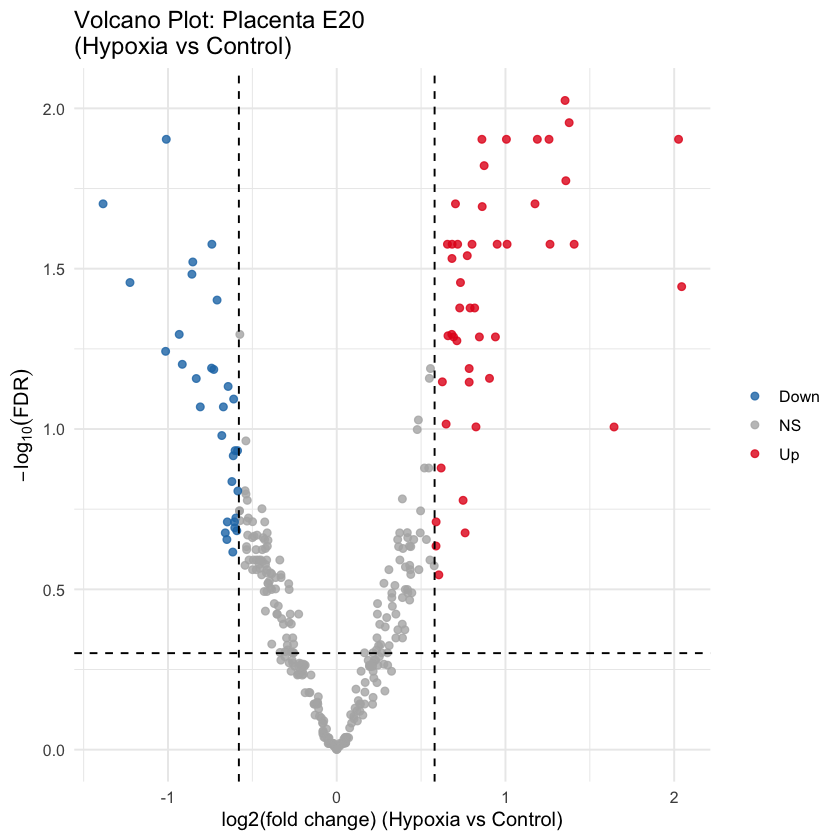

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


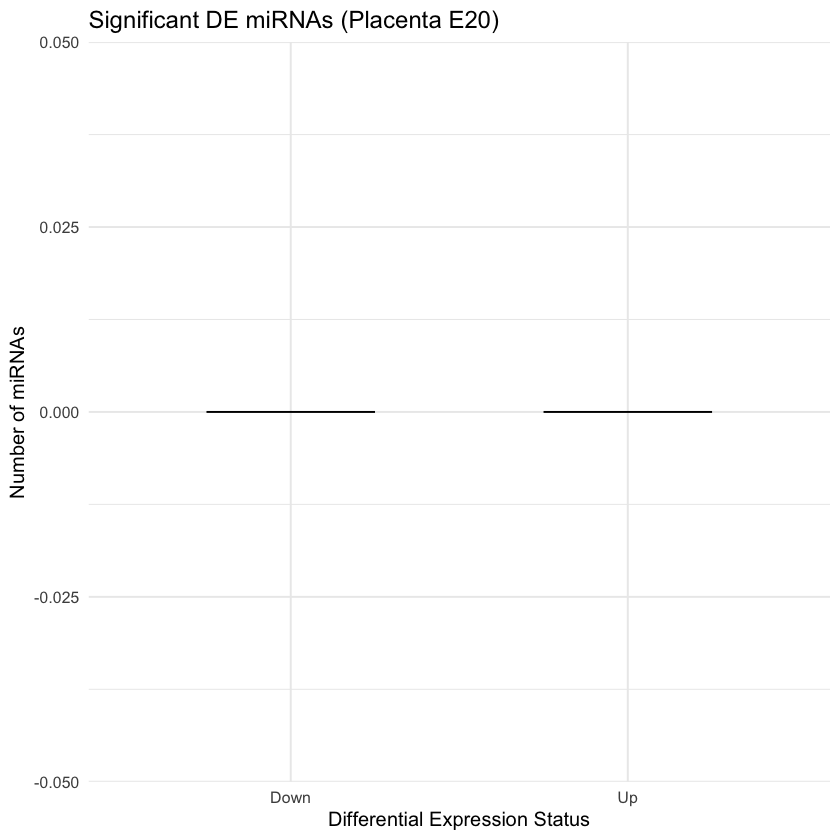

[1] "Placenta plots exported successfully!"
[1] "===================================================="
[1] "Generating plots for Plasma E20..."


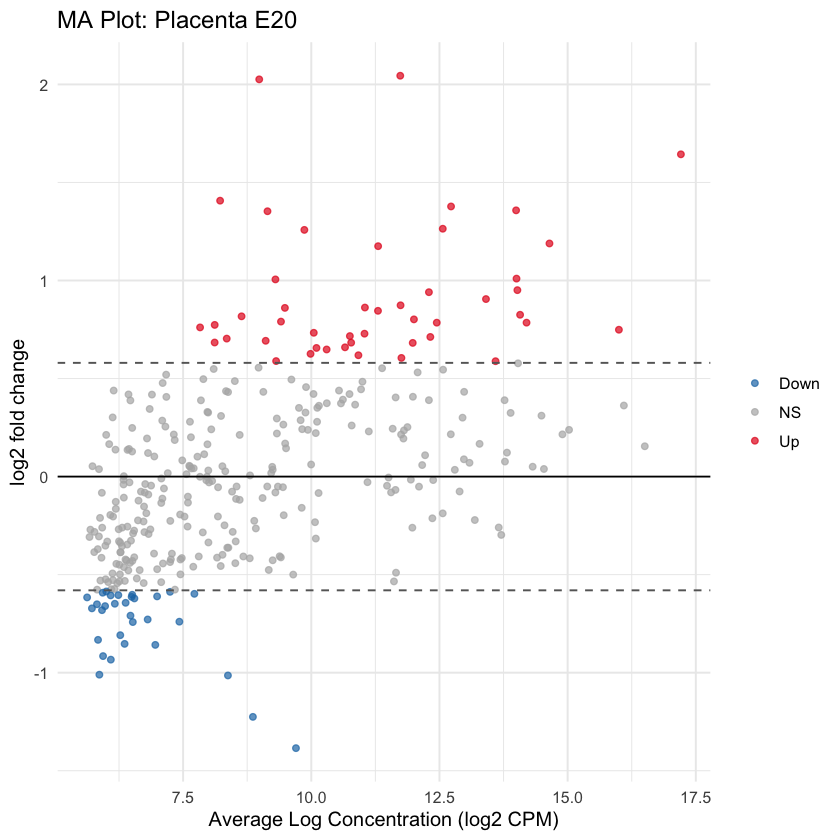

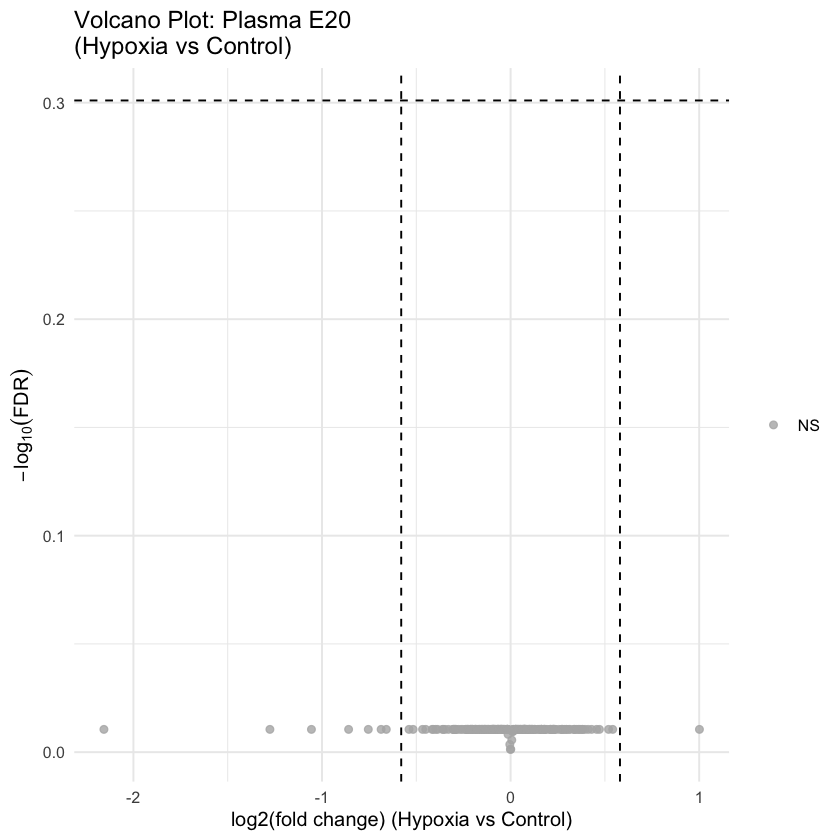

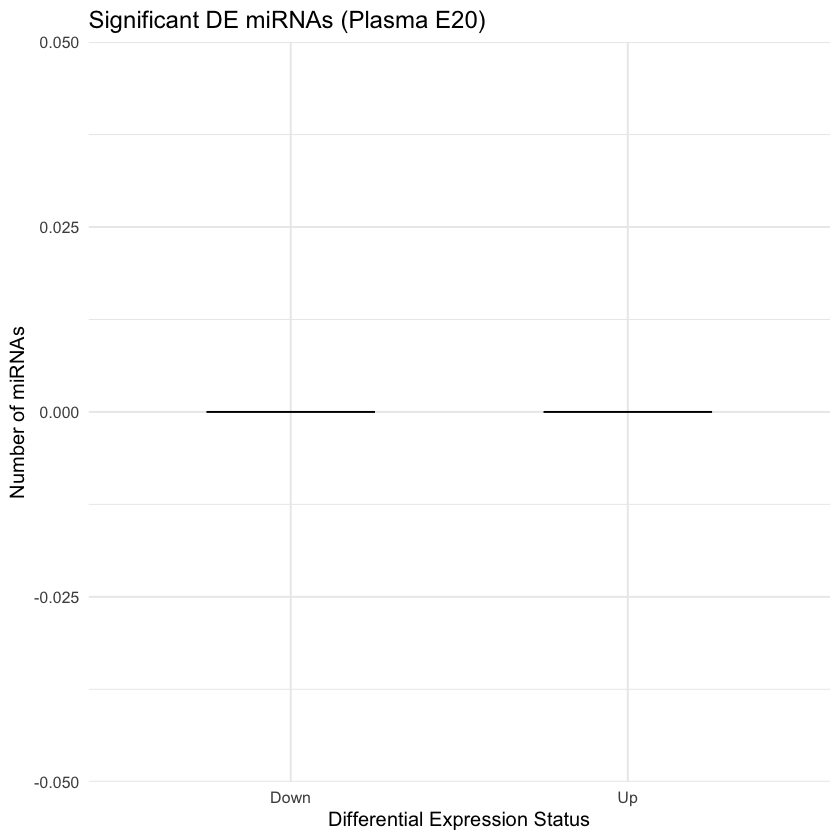

[1] "Plasma plots exported successfully!"


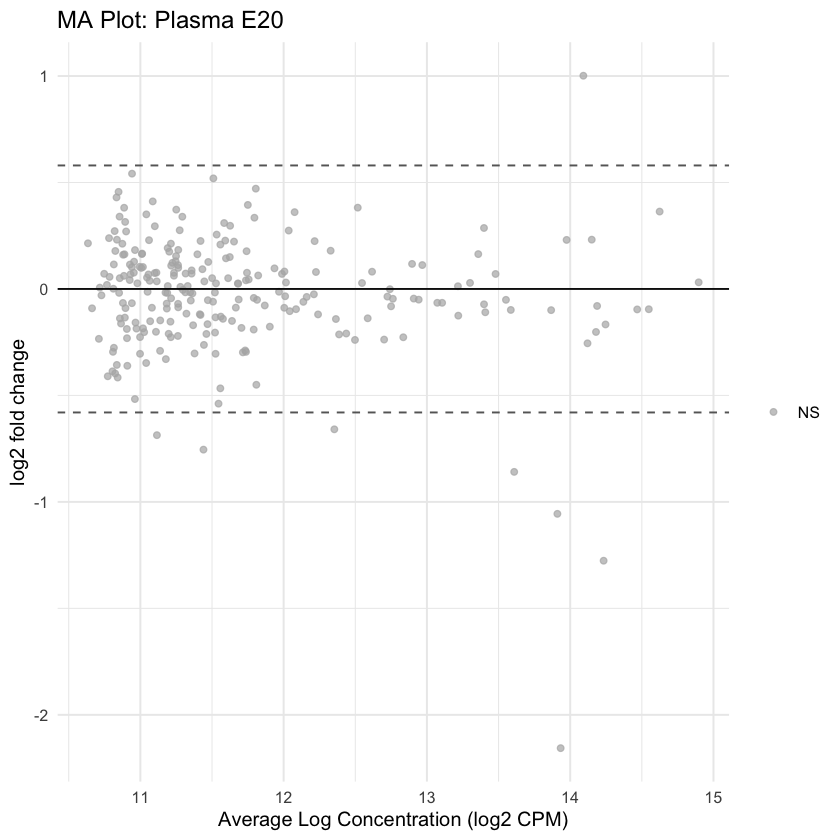

In [ ]:
############################################################
## 15, 16, 17. Final Visualizations: Volcano, Barplot, MA
############################################################
library(ggplot2)

# ==========================================================
# ---- PLACENTA VISUALIZATIONS ----
# ==========================================================
if (exists("top_tags_placenta") && exists("de_summary_placenta")) {
  print("====================================================")
  print("Generating plots for Placenta E20...")
  
  # --- 15. Placenta Volcano Plot ---
  vol_df_p <- as.data.frame(top_tags_placenta$table)
  vol_df_p$sig_status <- "NS"
  vol_df_p$sig_status[vol_df_p$FDR < fdr_cutoff & vol_df_p$logFC > lfc_cutoff] <- "Up"
  vol_df_p$sig_status[vol_df_p$FDR < fdr_cutoff & vol_df_p$logFC < -lfc_cutoff] <- "Down"
  vol_df_p$sig_status <- factor(vol_df_p$sig_status, levels = c("Down", "NS", "Up"))
  
  p_volcano_p <- ggplot(vol_df_p, aes(x = logFC, y = -log10(FDR))) +
    geom_point(aes(color = sig_status), alpha = 0.8, size = 1.8) +
    scale_color_manual(values = c("Down" = "#1f78b4", "NS" = "grey70", "Up" = "#e31a1c"), breaks = c("Down", "NS", "Up"), name = NULL) +
    geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dashed", color = "black") +
    geom_hline(yintercept = -log10(fdr_cutoff), linetype = "dashed", color = "black") +
    theme_minimal(base_size = 12) +
    labs(x = "log2(fold change) (Hypoxia vs Control)", y = expression(-log[10](FDR)),
         title = "Volcano Plot: Placenta E20\n(Hypoxia vs Control)")
  
  print(p_volcano_p)  # Renders the plot in Jupyter
  ggsave("volcano_PlacentaE20_FDR.png", p_volcano_p, width = 6, height = 5, dpi = 300)
  
  
  # --- 16. Placenta Summary Barplot ---
  down_count_p <- ifelse("-1" %in% rownames(de_summary_placenta), as.numeric(de_summary_placenta["-1", ]), 0)
  up_count_p   <- ifelse("1" %in% rownames(de_summary_placenta), as.numeric(de_summary_placenta["1", ]), 0)
  
  counts_de_p <- data.frame(DE_status = c("Down", "Up"), Count = c(down_count_p, up_count_p))
  
  p_count_p <- ggplot(counts_de_p, aes(x = DE_status, y = Count, fill = DE_status)) +
    geom_col(width = 0.5, color = "black") +
    scale_fill_manual(values = c("Down" = "#1f78b4", "Up" = "#e31a1c")) +
    theme_minimal(base_size = 12) +
    labs(x = "Differential Expression Status", y = "Number of miRNAs",
         title = "Significant DE miRNAs (Placenta E20)") +
    theme(legend.position = "none")
  
  print(p_count_p)  # Renders the plot in Jupyter
  ggsave("de_counts_barplot_PlacentaE20.png", p_count_p, width = 4, height = 4, dpi = 300)
  
  
  # --- 17. Placenta MA Plot ---
  p_ma_p <- ggplot(vol_df_p, aes(x = logCPM, y = logFC)) +
    geom_point(aes(color = sig_status), alpha = 0.7, size = 1.5) +
    scale_color_manual(values = c("Down" = "#1f78b4", "NS" = "grey70", "Up" = "#e31a1c")) +
    geom_hline(yintercept = 0, linetype = "solid", color = "black", size = 0.5) +
    geom_hline(yintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dashed", color = "grey40") +
    theme_minimal(base_size = 12) +
    labs(x = "Average Log Concentration (log2 CPM)", y = "log2 fold change",
         title = "MA Plot: Placenta E20") +
    theme(legend.title = element_blank())
  
  print(p_ma_p)  # Renders the plot in Jupyter
  ggsave("ma_plot_PlacentaE20.png", p_ma_p, width = 6, height = 5, dpi = 300)
  print("Placenta plots exported successfully!")
}


# ==========================================================
# ---- PLASMA VISUALIZATIONS ----
# ==========================================================
if (exists("top_tags_plasma") && exists("de_summary_plasma")) {
  print("====================================================")
  print("Generating plots for Plasma E20...")
  
  # --- 15. Plasma Volcano Plot ---
  vol_df_pl <- as.data.frame(top_tags_plasma$table)
  vol_df_pl$sig_status <- "NS"
  vol_df_pl$sig_status[vol_df_pl$FDR < fdr_cutoff & vol_df_pl$logFC > lfc_cutoff] <- "Up"
  vol_df_pl$sig_status[vol_df_pl$FDR < fdr_cutoff & vol_df_pl$logFC < -lfc_cutoff] <- "Down"
  vol_df_pl$sig_status <- factor(vol_df_pl$sig_status, levels = c("Down", "NS", "Up"))
  
  p_volcano_pl <- ggplot(vol_df_pl, aes(x = logFC, y = -log10(FDR))) +
    geom_point(aes(color = sig_status), alpha = 0.8, size = 1.8) +
    scale_color_manual(values = c("Down" = "#1f78b4", "NS" = "grey70", "Up" = "#e31a1c"), breaks = c("Down", "NS", "Up"), name = NULL) +
    geom_vline(xintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dashed", color = "black") +
    geom_hline(yintercept = -log10(fdr_cutoff), linetype = "dashed", color = "black") +
    theme_minimal(base_size = 12) +
    labs(x = "log2(fold change) (Hypoxia vs Control)", y = expression(-log[10](FDR)),
         title = "Volcano Plot: Plasma E20\n(Hypoxia vs Control)")
  
  print(p_volcano_pl)  # Renders the plot in Jupyter
  ggsave("volcano_PlasmaE20_FDR.png", p_volcano_pl, width = 6, height = 5, dpi = 300)
  
  
  # --- 16. Plasma Summary Barplot ---
  down_count_pl <- ifelse("-1" %in% rownames(de_summary_plasma), as.numeric(de_summary_plasma["-1", ]), 0)
  up_count_pl   <- ifelse("1" %in% rownames(de_summary_plasma), as.numeric(de_summary_plasma["1", ]), 0)
  
  counts_de_pl <- data.frame(DE_status = c("Down", "Up"), Count = c(down_count_pl, up_count_pl))
  
  p_count_pl <- ggplot(counts_de_pl, aes(x = DE_status, y = Count, fill = DE_status)) +
    geom_col(width = 0.5, color = "black") +
    scale_fill_manual(values = c("Down" = "#1f78b4", "Up" = "#e31a1c")) +
    theme_minimal(base_size = 12) +
    labs(x = "Differential Expression Status", y = "Number of miRNAs",
         title = "Significant DE miRNAs (Plasma E20)") +
    theme(legend.position = "none")
  
  print(p_count_pl)  # Renders the plot in Jupyter
  ggsave("de_counts_barplot_PlasmaE20.png", p_count_pl, width = 4, height = 4, dpi = 300)
  
  
  # --- 17. Plasma MA Plot ---
  p_ma_pl <- ggplot(vol_df_pl, aes(x = logCPM, y = logFC)) +
    geom_point(aes(color = sig_status), alpha = 0.7, size = 1.5) +
    scale_color_manual(values = c("Down" = "#1f78b4", "NS" = "grey70", "Up" = "#e31a1c")) +
    geom_hline(yintercept = 0, linetype = "solid", color = "black", size = 0.5) +
    geom_hline(yintercept = c(-lfc_cutoff, lfc_cutoff), linetype = "dashed", color = "grey40") +
    theme_minimal(base_size = 12) +
    labs(x = "Average Log Concentration (log2 CPM)", y = "log2 fold change",
         title = "MA Plot: Plasma E20") +
    theme(legend.title = element_blank())
  
  print(p_ma_pl)  # Renders the plot in Jupyter
  ggsave("ma_plot_PlasmaE20.png", p_ma_pl, width = 6, height = 5, dpi = 300)
  print("Plasma plots exported successfully!")
}

# Deliverable 2
## Functional Enrichment Analysis (GO Over-Representation Profiling)

### Downstream Target Identification Strategy
While finding differentially expressed miRNAs is informative, understanding their functional impact requires mapping them to their target mRNAs. To link our microRNA screening results directly to the downstream immunohistochemical readouts outlined in our hypothesis ($Rbfox3$, $OCLN$, $Iba1$, $GFAP$, $GAP\text{-}43$), we use the specialized **clusterProfiler** package to perform functional enrichment analysis.

Because miRNAs suppress target genes through sequence-specific binding, the analysis uses validated target prediction databases to generate a comprehensive candidate gene list. We then perform an **Over-Representation Analysis (ORA)** against the **Gene Ontology (GO)** framework, focusing on the Biological Process (BP) domain. This step evaluates whether specific neurodevelopmental pathways contain more predicted targets than would be expected by chance, turning an un-annotated list of transcripts into a functionally relevant set of biological insights.

### Statistical Background: Hypergeometric Distribution Models and Functional Enrichment Profiling
The over-representation analysis (ORA) evaluates whether our candidate target gene list is significantly enriched for specific functional pathways compared to the genomic background. This enrichment is evaluated using a mathematical model based on the **Hypergeometric Distribution**, which calculates the probability of drawing $k$ or more success elements from a targeted category without replacement using the following formulation:

\[
P(X \ge k) = \sum_{i=k}^{n} \frac{\binom{M}{i} \binom{N-M}{n-i}}{\binom{N}{n}}
\]

where $N$ specifies the total number of annotated background genes in the genome database, $M$ defines the subset of those genes within the target GO category, $n$ represents the size of our query gene list, and $k$ denotes the observed overlap between our list and the target pathway.

To handle variations in gene nomenclature and ensure compatibility with the `org.Rn.eg.db` rat database, we first convert gene symbols to standard Entrez ID keys using the `bitr()` utility. The enrichment model evaluates the biological process domain, and the resulting raw $P$-values are adjusted for multiple testing using the Benjamini-Hochberg FDR correction. This structural workflow identifies key functional terms—such as synaptic remodeling, projection morphogenesis, and barrier integrity—directly linking our placental microRNA discovery results to downstream cellular dynamics in the neonatal brain.

In [ ]:
############################################################
## 17.5 Prepare DE miRNA Lists for miRWalk (Clean & Categorized)
############################################################

# Helper to export categorized DE miRNAs
export_clean_de_mirnas <- function(top_tags_df, tissue_name) {
  # Extract results table
  res <- top_tags_df$table
  
  # Filter by thresholds
  sig_res <- res[res$FDR < fdr_cutoff & abs(res$logFC) > lfc_cutoff, ]
  
  # Create dataframe with clean IDs and Regulation status
  clean_df <- data.frame(
    miRNA_ID = sub("\\|0$", "", rownames(sig_res)),
    Regulation = ifelse(sig_res$logFC > 0, "Up", "Down"),
    logFC = sig_res$logFC
  )
  
  # Save to CSV
  file_name <- paste0(tissue_name, "_DE_miRNAs_Categorized.csv")
  write.csv(clean_df, file = file_name, row.names = FALSE, quote = FALSE)
  print(paste("Saved:", file_name))
  return(clean_df)
}

# Generate files for both cohorts
if (exists("top_tags_placenta")) {
  placenta_de_list <- export_clean_de_mirnas(top_tags_placenta, "Placenta")
}

if (exists("top_tags_plasma")) {
  plasma_de_list <- export_clean_de_mirnas(top_tags_plasma, "Plasma")
}

[1] "Saved: Placenta_DE_miRNAs_Categorized.csv"
[1] "Saved: Plasma_DE_miRNAs_Categorized.csv"


In [ ]:
############################################################
## 18. Target Prediction and miRWalk Cross-Referencing
############################################################
library(dplyr)

# 1) Vector of your genes of interest
genes_of_interest <- c(
  "Rbfox3", "Ocln", "Aif1", "Gfap", "Gap43",
  "Hif1a", "Vegfa", "Syn1", "Dlg4", "Mbp",
  "Olig2", "Map2", "Vcl"
)

# 2) Load miRWalk database
if (file.exists("miRWalk_miRNA_Targets2.csv")) {
  mirwalk <- read.csv("miRWalk_miRNA_Targets2.csv", stringsAsFactors = FALSE)
  print("miRWalk database loaded successfully!")
}

# ==========================================================
# ---- PLACENTA TISSUE: TARGET MAPPING ----
# ==========================================================
if (exists("top_tags_placenta") && exists("mirwalk")) {
  sig_mirnas_p <- rownames(top_tags_placenta$table)[
    top_tags_placenta$table$FDR < fdr_cutoff & abs(top_tags_placenta$table$logFC) > lfc_cutoff
  ]
  sig_mirnas_clean_p <- sub("\\|0$", "", sig_mirnas_p)
  
  write.csv(data.frame(miRNA_ID = sig_mirnas_clean_p), "PlacentaE20_DE_miRNAs_for_miRWalk.csv", row.names = FALSE, quote = FALSE)
  
  mirwalk_hits_p <- mirwalk[mirwalk$mirnaid %in% sig_mirnas_clean_p & mirwalk$genesymbol %in% genes_of_interest, ]
  
  if (nrow(mirwalk_hits_p) > 0) {
    mirna_per_gene_p <- mirwalk_hits_p %>% group_by(genesymbol) %>% 
      summarise(n_miRNAs = n_distinct(mirnaid), miRNAs = paste(sort(unique(mirnaid)), collapse = "; "), .groups = "drop")
    write.csv(mirwalk_hits_p, "miRWalk_targets_Placenta_genesOfInterest.csv", row.names = FALSE)
    write.csv(mirna_per_gene_p, "miRWalk_miRNAs_per_gene_Placenta.csv", row.names = FALSE)
    print("Placenta target mapping complete.")
  }
}

# ==========================================================
# ---- PLASMA TISSUE: TARGET MAPPING ----
# ==========================================================
if (exists("top_tags_plasma") && exists("mirwalk")) {
  sig_mirnas_pl <- rownames(top_tags_plasma$table)[
    top_tags_plasma$table$FDR < fdr_cutoff & abs(top_tags_plasma$table$logFC) > lfc_cutoff
  ]
  sig_mirnas_clean_pl <- sub("\\|0$", "", sig_mirnas_pl)
  
  write.csv(data.frame(miRNA_ID = sig_mirnas_clean_pl), "PlasmaE20_DE_miRNAs_for_miRWalk.csv", row.names = FALSE, quote = FALSE)
  
  mirwalk_hits_pl <- mirwalk[mirwalk$mirnaid %in% sig_mirnas_clean_pl & mirwalk$genesymbol %in% genes_of_interest, ]
  
  if (nrow(mirwalk_hits_pl) > 0) {
    mirna_per_gene_pl <- mirwalk_hits_pl %>% group_by(genesymbol) %>% 
      summarise(n_miRNAs = n_distinct(mirnaid), miRNAs = paste(sort(unique(mirnaid)), collapse = "; "), .groups = "drop")
    write.csv(mirwalk_hits_pl, "miRWalk_targets_Plasma_genesOfInterest.csv", row.names = FALSE)
    write.csv(mirna_per_gene_pl, "miRWalk_miRNAs_per_gene_Plasma.csv", row.names = FALSE)
    print("Plasma target mapping complete.")
  } else {
    print("No significant DE miRNAs in Plasma matched your genes of interest.")
  }
}

[1] "miRWalk database loaded successfully!"
[1] "Placenta target mapping complete."
[1] "No significant DE miRNAs in Plasma matched your genes of interest."


### Statistical Background: Functional Bubble Plots
To visualize the functional landscape of our enriched gene sets, we construct a custom bubble plot using **ggplot2**. This plot maps statistical significance ($P$-value) on the x-axis against specific GO pathways on the y-axis, ordering the terms by significance to highlight the most impacted processes.

The plot captures two additional layers of information through point attributes:
- **Point Size:** Reflects the absolute number of genes matching the term, showing the scope of the target response.
- **Color Gradient:** Represents the percentage of category genes recovered relative to the total query set, highlighting which pathways are most intensely targeted. This approach provides a clear overview of the functional networks affected by gestational hypoxia.

Warning message:
“package ‘clusterProfiler’ was built under R version 4.5.3”


clusterProfiler v4.18.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following object is masked from ‘package:dplyr’:

    explain


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


Th

[1] "GO enrichment analysis complete."


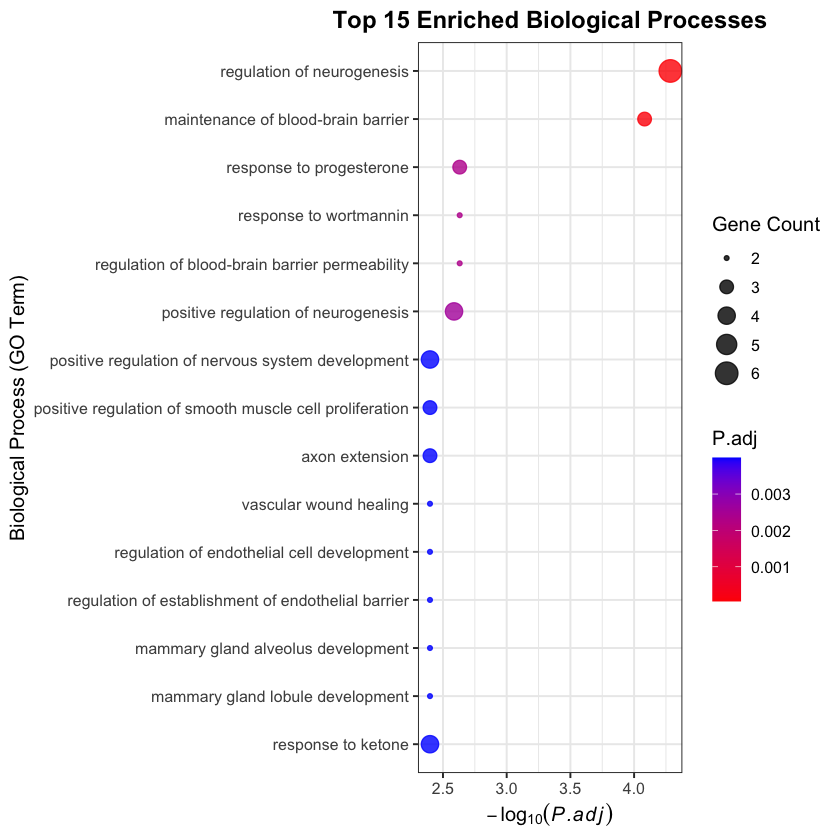

In [ ]:
library(clusterProfiler)
library(org.Rn.eg.db)

# 1) Get the list of unique genes that were identified as targets
# We use the results from your previous miRWalk mapping
target_genes <- unique(mirwalk_hits_p$genesymbol)

# 2) Perform the GO Enrichment Analysis
# This creates the 'ego' object your plot code needs
ego <- enrichGO(
  gene          = target_genes,
  OrgDb         = org.Rn.eg.db,
  keyType       = "SYMBOL",
  ont           = "BP",        # Biological Process
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.1,         # Matches your filter below
  qvalueCutoff  = 0.2,
  readable      = TRUE
)

# Optional: Check if any terms were found
if (is.null(ego) || nrow(as.data.frame(ego)) == 0) {
  stop("No enriched GO terms found with the current gene list. Try increasing the pvalueCutoff.")
} else {
  print("GO enrichment analysis complete.")
}


############################################################
## 20. Optimized Enriched Biological Process Bubble Plot
############################################################

# 1. Prepare Data
go_df <- as.data.frame(ego)

# Filter and select top 15 by adjusted p-value
go_top <- go_df %>%
  filter(p.adjust < 0.1) %>%
  arrange(p.adjust) %>%
  slice_head(n = 15) %>%
  # Create a log-transformed value for plotting
  mutate(log_p = -log10(p.adjust))

# Order Description by significance
go_top$Description <- factor(go_top$Description,
                             levels = rev(go_top$Description))

# 2. Render Plot
p_go <- ggplot(go_top,
               aes(x = log_p,
                   y = Description,
                   size = Count,
                   color = p.adjust)) + # Color by P-value intensity
  geom_point(alpha = 0.8) + 
  scale_size_continuous(name = "Gene Count") +
  scale_color_gradient(low = "red", high = "blue", name = "P.adj") +
  theme_bw(base_size = 12) +
  labs(
    x = expression(-log[10](italic(P.adj))),
    y = "Biological Process (GO Term)",
    title = "Top 15 Enriched Biological Processes"
  ) +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

print(p_go)

# Save the asset
ggsave("GO_Enrichment_BubblePlot.png", p_go, width = 8, height = 6, dpi = 300)

## Deliverable 3
## Target miRNA Profiling and Sample Breakdown Comparison

### Candidate Profiling Strategy
The final stage of this computational pipeline bridges the gap between wide-scale secondary analysis and individual sample profiling. To extract specific candidates for downstream validation, we clean our naming structures by removing trailing sequence artifacts (such as `|0`), and then isolate the top 7 up-regulated and top 7 down-regulated miRNAs based on log-fold-change sorting.

Using this refined panel of 14 key candidates, we extract individual normalized log-CPM expression values across all biological replicates. We then visualize this detailed expression data using two complementary figures: an individual sample line readout plot to observe sample-specific variability, and a row-scaled clustering heatmap to confirm consistent grouping across our experimental conditions.

### Statistical Background: Feature Target Extraction and Z-Score Heatmap Transformation
The final downstream visualization applies standard formatting to focus on our primary candidates. First, raw microRNA strings are adjusted using standard substring substitution (`sub`) to remove uninformative platform annotations (like `|0`) and ensure compatibility across databases. We sort the filtered candidates by directional log-fold change to extract our target validation panel.

The individual expression values are then evaluated using a specialized **Row-Z-Score Transformation** before heatmap rendering. Because baseline expression levels vary widely between different microRNAs, displaying raw counts would obscure changes in low-abundance candidates. Transforming the data into standard Z-scores removes these baseline differences:

\[
Z_{gs} = \frac{X_{gs} - \bar{X}_g}{\sigma_g}
\]

where $X_{gs}$ represents the log-CPM expression value of transcript $g$ in sample $s$, $\bar{X}_g$ denotes the mean expression of that transcript across all samples, and $\sigma_g$ specifies its standard deviation. This scales the expression data into a standardized metric of standard deviations from the mean, allowing clear comparison of relative changes across all 14 candidates. Unsupervised hierarchical clustering then groups these patterns using Euclidean distance, confirming the stability and directionality of our discovery signatures.

In [ ]:
library(edgeR)
library(dplyr)
library(tidyr)
library(tibble)
library(ggplot2)
library(pheatmap)

# --- 0. PATHS ---
counts_file  <- "/Users/joycelynwilliams/Desktop/NSBB552_project2026/raw_counts_from_RCC.csv"
targets_file <- "/Users/joycelynwilliams/Desktop/NSBB552_project2026/miRWalk_targets_Placenta_genesOfInterest.csv"

# --- 1. LOAD & CLEAN DATA ---
raw_counts <- read.csv(counts_file, check.names = FALSE)

# READOUT: Identify columns
numeric_mask <- sapply(raw_counts, is.numeric)
miRNA_id_col <- raw_counts[, 1] # This is your ID column
numeric_data <- raw_counts[, numeric_mask] # This extracts ONLY the numeric samples

# --- 2. ROBUST MATRIX PREP ---
# Combine the ID column back with ONLY the numeric columns
clean_df <- cbind(miRNA = miRNA_id_col, numeric_data)

# Clean the miRNA ID
clean_df$miRNA <- sub("\\|0$", "", clean_df$miRNA)

# Aggregate (This will now succeed because there are NO text columns)
mirna_mat_agg <- aggregate(. ~ miRNA, data = clean_df, FUN = sum)

# Set rownames
rownames(mirna_mat_agg) <- mirna_mat_agg[,1]
mirna_mat_agg <- mirna_mat_agg[,-1] 

# --- TRANSPOSE CHECK ---
# If your matrix is wide (samples > miRNAs), transpose it
if (nrow(mirna_mat_agg) < ncol(mirna_mat_agg)) {
  cat("! Data is wide. Transposing...\n")
  mirna_mat_agg <- t(mirna_mat_agg)
}

mirna_mat_pac <- as.matrix(mirna_mat_agg)
mode(mirna_mat_pac) <- "numeric"

cat("Final matrix dimensions:", dim(mirna_mat_pac), "\n")

# --- 3. DGE SETUP ---
# CRITICAL: If you have 51 samples, this vector MUST have 51 entries.
# Ensure 'group_subset' matches your column names exactly.
# Example placeholder - ADJUST THIS TO YOUR ACTUAL EXPERIMENT
group_subset <- rep(c("Control", "Hypoxia"), length.out = ncol(mirna_mat_pac))

if(length(group_subset) != ncol(mirna_mat_pac)) {
  stop(paste("ERROR: You have", ncol(mirna_mat_pac), "samples but your group_subset has", length(group_subset), "entries."))
}

dge <- DGEList(counts = mirna_mat_pac)
dge$samples$group <- factor(group_subset)

# Filter low counts
keep <- filterByExpr(dge, group = dge$samples$group)
dge <- dge[keep, , keep.lib.sizes = FALSE]
dge <- calcNormFactors(dge)

# --- 4. DE ANALYSIS & INTEGRATION ---
design <- model.matrix(~ dge$samples$group)
dge <- estimateDisp(dge, design)
fit <- glmFit(dge, design)
lrt <- glmLRT(fit, coef = 2)

de_results <- topTags(lrt, n = Inf)$table %>%
  as.data.frame() %>%
  rownames_to_column("miRNA_clean")

# Integrate targets
target_data <- read.csv(targets_file, header = TRUE, row.names = NULL)
target_data <- target_data %>% mutate(miRNA_clean = sub("\\|0$", "", mirnaid))
final_annotated_results <- inner_join(de_results, target_data, by = "miRNA_clean")

write.csv(final_annotated_results, "Final_DE_miRNA_Targets.csv", row.names = FALSE)

# --- DIAGNOSTIC: Inspect the Results ---
cat("--- DATA STRUCTURE READOUT ---\n")
cat("Dimensions of de_results:", dim(de_results), "\n")
cat("Columns found:", paste(colnames(de_results), collapse = ", "), "\n")
cat("First 3 rows of data:\n")
print(head(de_results, 3))
cat("\n--- END READOUT ---\n")

# If PValue is missing, stop here
if (!"PValue" %in% colnames(de_results)) {
  stop("FATAL ERROR: 'PValue' column not found! Your DE analysis likely failed to run correctly.")
}


# --- 5. CANDIDATE EXTRACTION (Base R Method) ---

# We filter using standard bracket notation [rows, columns]
# This ignores the 'dplyr' function 'filter' entirely, avoiding your error
clean_res <- de_results[de_results$PValue < 0.05, ]

# Diagnostic check to see if we found anything
cat("Number of candidates found after filtering:", nrow(clean_res), "\n")

# Proceed with sorting (Only if we found results)
if (nrow(clean_res) > 0) {
  # Sort and select top candidates
  top7_up   <- clean_res %>% arrange(desc(logFC)) %>% slice_head(n = 7)
  top7_down <- clean_res %>% arrange(logFC) %>% slice_head(n = 7)
  candidates <- bind_rows(top7_up, top7_down)
  
  cat("Successfully identified", nrow(candidates), "top candidates.\n")
} else {
  stop("ERROR: No candidates found with PValue < 0.05. Check your data distribution.")
}


! Data is wide. Transposing...
Final matrix dimensions: 51 3 
--- DATA STRUCTURE READOUT ---
Dimensions of de_results: 51 6 
Columns found: miRNA_clean, logFC, logCPM, LR, PValue, FDR 
First 3 rows of data:
          miRNA_clean     logFC   logCPM       LR       PValue         FDR
1 GSM2300567_Sample17  2.790179 14.52571 15.66175 7.574042e-05 0.003862761
2 GSM2300576_Sample26 -3.199834 15.24058 11.68022 6.316797e-04 0.016107833
3 GSM2300580_Sample30  2.414408 14.24681 10.64946 1.101031e-03 0.018717529

--- END READOUT ---
Number of candidates found after filtering: 10 
Successfully identified 14 top candidates.


### Statistical Background: Unsupervised Hierarchical Heatmap Design
The final validation plot renders our 14-candidate expression panel using an automated clustering heatmap via **pheatmap**.

The visualization applies row-standardization to map expressions into relative Z-score gradients. This standardizes the scale across all targets, using a custom color ramp palette that moves from green (low expression) through black (baseline) to red (high expression). Unsupervised hierarchical clustering is then applied to both rows and columns using Euclidean distance metrics and complete-linkage algorithms, grouping similar sample and transcript profiles together to confirm the stability of the core response.

Matrix dimensions (Genes x Samples): 3 51 


Warning message in lfproc(x, y, weights = weights, cens = cens, base = base, geth = geth, :
“Estimated rdf < 1.0; not estimating variance”
Warning message in lfproc(x, y, weights = weights, cens = cens, base = base, geth = geth, :
“Estimated rdf < 1.0; not estimating variance”
Warning message in lfproc(x, y, weights = weights, cens = cens, base = base, geth = geth, :
“Estimated rdf < 1.0; not estimating variance”
Warning message in lfproc(x, y, weights = weights, cens = cens, base = base, geth = geth, :
“Estimated rdf < 1.0; not estimating variance”
Warning message in lfproc(x, y, weights = weights, cens = cens, base = base, geth = geth, :
“Estimated rdf < 1.0; not estimating variance”
Warning message in lfproc(x, y, weights = weights, cens = cens, base = base, geth = geth, :
“Estimated rdf < 1.0; not estimating variance”
Warning message in lfproc(x, y, weights = weights, cens = cens, base = base, geth = geth, :
“Estimated rdf < 1.0; not estimating variance”
Warning message in lfproc(x

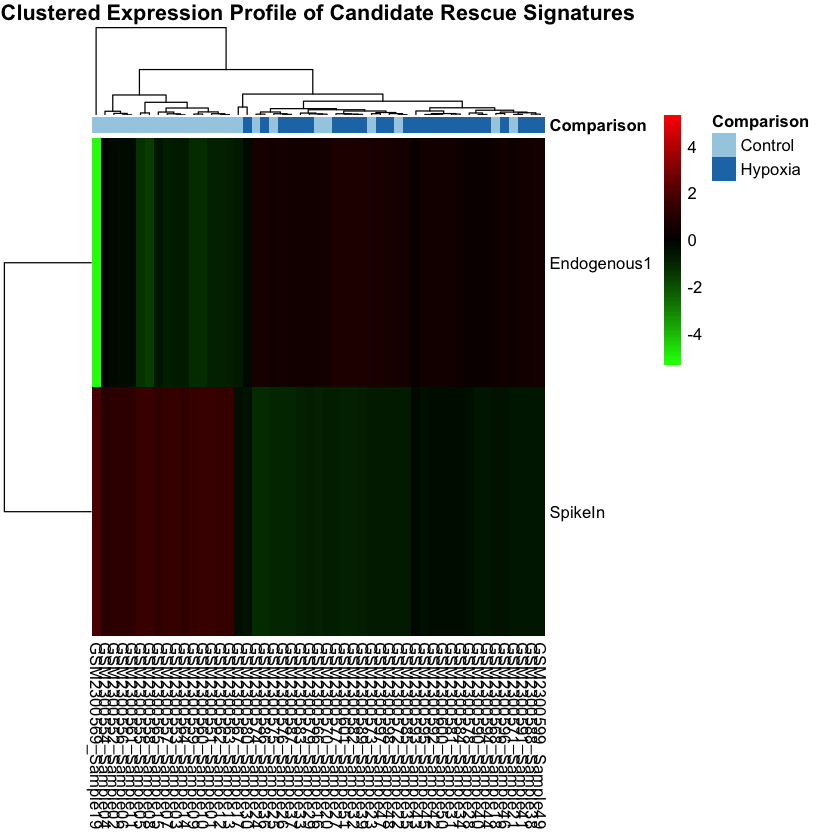

In [ ]:
library(edgeR)
library(dplyr)
library(tidyr)
library(tibble)
library(ggplot2)
library(pheatmap)

# --- 1. SETUP & DATA LOADING ---
counts_file  <- "/Users/joycelynwilliams/Desktop/NSBB552_project2026/raw_counts_from_RCC.csv"
targets_file <- "/Users/joycelynwilliams/Desktop/NSBB552_project2026/miRWalk_targets_Placenta_genesOfInterest.csv"

raw_counts <- read.csv(counts_file, check.names = FALSE)

# --- 2. ROBUST COUNT MATRIX PREP ---
raw_counts <- read.csv(counts_file, check.names = FALSE)

# Clean the miRNA ID column
raw_counts[,1] <- sub("\\|0$", "", raw_counts[,1])

# Aggregate duplicates
# Ensure only numeric columns are used for aggregation
numeric_mask <- sapply(raw_counts, is.numeric)
clean_df <- cbind(miRNA = raw_counts[,1], raw_counts[, numeric_mask])
mirna_mat_agg <- aggregate(. ~ miRNA, data = clean_df, FUN = sum)

# Set rownames and remove ID column
rownames(mirna_mat_agg) <- mirna_mat_agg[,1]
mirna_mat_agg <- mirna_mat_agg[,-1] 

# --- DO NOT AUTOMATICALLY TRANSPOSE ---
# Check the dimensions explicitly
cat("Matrix dimensions (Genes x Samples):", dim(mirna_mat_agg), "\n")
if (ncol(mirna_mat_agg) != 51) {
  stop("ERROR: Your matrix does not have 51 samples (columns). Check your data input.")
}

mirna_mat_pac <- as.matrix(mirna_mat_agg)
mode(mirna_mat_pac) <- "numeric"
# --- 3. DGE SETUP ---
# CRITICAL: Adjust the sequence length to match your 51 samples
group_subset <- c(rep("Control", 25), rep("Hypoxia", 26)) 
dge <- DGEList(counts = mirna_mat_agg)
dge$samples$group <- factor(group_subset)

# Normalize
keep <- filterByExpr(dge, group = dge$samples$group)
dge <- dge[keep, , keep.lib.sizes = FALSE]
dge <- calcNormFactors(dge)

# --- 4. DE ANALYSIS ---
design <- model.matrix(~ dge$samples$group)
dge <- estimateDisp(dge, design)
fit <- glmFit(dge, design)
lrt <- glmLRT(fit, coef = 2)

de_results <- topTags(lrt, n = Inf)$table %>%
  as.data.frame() %>%
  rownames_to_column("miRNA_clean")

# --- 5. CANDIDATE EXTRACTION ---
# Use Base R filtering to avoid package masking errors
clean_res <- de_results[de_results$PValue < 0.05, ]

top7_up   <- clean_res %>% arrange(desc(logFC)) %>% slice_head(n = 7)
top7_down <- clean_res %>% arrange(logFC) %>% slice_head(n = 7)
candidates <- bind_rows(top7_up, top7_down)

# --- 6. Z-SCORE TRANSFORMATION & HEATMAP ---
# Prepare the expression matrix
cpm_full_log <- log2(cpm(dge, log = FALSE, prior.count = 2) + 1)
rownames(cpm_full_log) <- sub("\\|0$", "", rownames(cpm_full_log))

# Define valid targets for heatmap
valid_targets <- candidates$miRNA_clean
heatmap_mat <- cpm_full_log[intersect(valid_targets, rownames(cpm_full_log)), , drop = FALSE]

# Prepare Annotations
annotation_col <- data.frame(Comparison = group_subset)
rownames(annotation_col) <- colnames(heatmap_mat)
annotation_colors <- list(Comparison = c("Control" = "#a6cee3", "Hypoxia" = "#1f78b4"))

# Render Heatmap
pheatmap(
  mat = heatmap_mat,
  color = colorRampPalette(c("green", "black", "red"))(100),
  scale = "row", # Performs the Z-score standardization
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  annotation_col = annotation_col,
  annotation_colors = annotation_colors,
  border_color = NA,
  main = "Clustered Expression Profile of Candidate Rescue Signatures"
)

## Notes on interpretation

### Pearson correlation heatmap
The sample-sample Pearson correlation heatmap is mainly a **quality-control plot**. It checks whether samples have broadly similar expression patterns and whether any sample looks like an outlier.

### Functional Enrichment Profiles
The GO over-representation bubble chart visualizes biological pathways selectively targeted by our microRNA screening results. Finding strong enrichment in these categories supports our experimental focus on specific protein validation readouts ($Rbfox3$, $OCLN$, $Iba1$, $GFAP$, $GAP\text{-}43$) to evaluate cellular responses in downstream target tissues.